# **Machine Learning Models for Depression Risk Classification | 2 - Modeling**

**Author:** [Aleksandra Pozorska](https://www.linkedin.com/in/aleksandra-pozorska/)

### Project Description

This project focuses on predicting the risk of depression using anonymized survey data. The dataset used in this project includes a rich set of features: demographic details (e.g., age, gender, city), academic and occupational factors (e.g., CGPA, work/study hours, satisfaction levels, pressure), lifestyle habits (e.g., sleep patterns, dietary behavior), and psychological indicators (e.g., financial stress, history of suicidal thoughts, family history of mental illness).

By analyzing these multidimensional factors, the project aims to uncover key patterns and build a machine learning model capable of reliably identifying individuals at higher risk of depression, contributing to more proactive mental health support systems.

### Objectives  
- Build a robust, reliable and interpretable machine learning pipeline to predict depression risk based on survey responses.
- Explore the impact of lifestyle, academic, and work-related stress on mental health
  
---

### Dataset Description  

The dataset consists of three files:

- **full_data.csv**: Training data with depression labels  
- **external_data.csv**: Test data (external data without labels)

### Column Descriptions 

- **Name** (`name`) :  Identifier for participants (anonymized)  
- **Gender** (`gender`): Participant's gender identity  
- **Age** (`age`): Participant's age  
- **City** (`city`): Location of residence  
- **Working Professional or Student** (`occupation_status`): Current occupation category  
- **Profession** (`profession`): Specific profession/field of work  
- **Degree** (`degree`): Educational qualification  
- **CGPA** (`cgpa`): Academic performance measure  
- **Academic Pressure** (`academic_pressure`): Level of pressure from academic responsibilities  
- **Work Pressure** (`work_pressure`): Level of pressure from work responsibilities  
- **Study Satisfaction** (`study_satisfaction`): Level of satisfaction with studies  
- **Job Satisfaction** (`job_satisfaction`): Level of satisfaction with current job  
- **Work/Study Hours** (`work_study_hours`): Daily hours spent on work/study  
- **Sleep Duration** (`sleep_duration`): Average daily sleep hours  
- **Dietary Habits** (`dietary_habits`): Eating patterns and food preferences  
- **Have you ever had suicidal thoughts?** (`suicidal_thoughts`): History of suicidal ideation (Yes/No)  
- **Financial Stress** (`financial_stress`): Level of stress related to financial situation  
- **Family History of Mental Illness** (`family_history_mental_illness`): Presence of mental illness in family (Yes/No)  
- **Target Variable: Depression** (`depression`): Binary indicator (1 = Yes, 0 = No) of depression risk
  
---

### Methodology:
- Load data
- Data preparation & exploration
- Preprocessing 
- Feature selection
- Training and hyperparameter tuning
- Evaluation
- Model selection & prediction
- Deployment
---

### Notebooks

There are two notebooks: 
- **Part 1** - Data Exploration and Preprocessing. It prepares clean, encoded features and exports artifacts for Part 2.
- **Part 2** - Modeling. It loads artifacts, runs model comparisons, cross‑validation, threshold selection, and tuning.


# 0. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any
import joblib
from sklearn import metrics

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder, TargetEncoder, KBinsDiscretizer
from sklearn.impute import SimpleImputer

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

import keras
import tensorflow as tf
from keras import layers
from scikeras.wrappers import KerasClassifier
from keras.callbacks import EarlyStopping


# 1. Load files

In [25]:
class InconsistencyFlagger(BaseEstimator, TransformerMixin):
    """
    Adds an 'inconsistency_flag' column to the DataFrame, marking rows with logical inconsistencies
    based on pressure, satisfaction, and occupation/profession fields.
    """
    def __init__(self):
        pass

    def fit(self, X: pd.DataFrame, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        X['inconsistency_flag'] = (
            ((X['work_pressure'] > 0) & (X['academic_pressure'] > 0)).astype(int) +
            ((X['study_satisfaction'] > 0) & (X['job_satisfaction'] > 0)).astype(int) +
            (
                ((X['occupation_status'] == 'Working Professional') & (X['profession'] == 'Student')) |
                ((X['occupation_status'] == 'Student') & (X['profession'] != 'Student') & (X['profession'].notna()))
            ).astype(int)
        )
        return X


class ConditionalFlagger(BaseEstimator, TransformerMixin):
    """
    Adds binary flag columns for missing values in specified columns, using user-defined conditional rules.
    Flags are set as 'not applicable' or 'imputed' depending on another column's value, as defined in the flagging_map dictionary.
    """
    def __init__(self, flagging_map, suffix_map=None):
        self.flagging_map = flagging_map
        self.suffix_map = suffix_map or {'not_applicable': '_not_applicable', 'imputed': '_imputed'}

    def fit(self, X: pd.DataFrame, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        for col, conditions in self.flagging_map.items():
            for flag_type, cond in conditions.items():
                cond_col, cond_val = list(cond.items())[0]
                mask = (X[cond_col] == cond_val) & (X[col].isna())
                flag_col = f"{col}{self.suffix_map[flag_type]}"
                X[flag_col] = 0
                X.loc[mask, flag_col] = 1
        return X

class RelationalImputer(BaseEstimator, TransformerMixin):
    """
    Conditionally imputes missing values in specified columns based on another column's value.
    Args:
        cols_to_impute (list of str): Columns to impute missing values in.
        condition_col (str): Column used to define the imputation condition.
        condition_value (str): Value in `condition_col` that triggers imputation
        strategy (str, default='constant'): Imputation strategy ('constant', 'median', or 'most_frequent').
        fill_value (any, optional): Value to use for 'constant' strategy.
    Raises:
        ValueError: If strategy is invalid or required columns are missing.
    """

    def __init__(self,
                 cols_to_impute: list["str"],
                 condition_col: str,
                 condition_value: str,
                 strategy: str = 'constant',
                 fill_value: Any = None
                 ):
        self.cols_to_impute = cols_to_impute
        self.condition_col = condition_col
        self.condition_value = condition_value
        self.strategy = strategy
        self.fill_value = fill_value
        self.medians_ = {}
        self.modes_ = {}
        if strategy not in ['constant', 'median', 'most_frequent']:
            raise ValueError("Unknown strategy. Choose: 'constant', 'median' or 'most_frequent'")
        if strategy == 'constant' and fill_value is None:
            raise ValueError("fill_value must be set for 'constant' strategy.")

    def fit(self, X: pd.DataFrame, y=None) -> "RelationalImputer":
        """Learn imputation values from data where condition is met."""
        required_cols = set(self.cols_to_impute) | {self.condition_col}
        missing_cols = required_cols - set(X.columns)
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")

        mask = X[self.condition_col] == self.condition_value
        if self.strategy == 'median':
            for col in self.cols_to_impute:
                self.medians_[col] = X.loc[mask, col].median()
        elif self.strategy == 'most_frequent':
            for col in self.cols_to_impute:
                mode_series = X.loc[mask, col].mode(dropna=True)
                self.modes_[col] = mode_series.iloc[0] if not mode_series.empty else self.fill_value
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """Impute missing values where condition is met."""
        X = X.copy()
        for col in self.cols_to_impute:
            mask = (X[self.condition_col] == self.condition_value) & (X[col].isna())
            if self.strategy == 'median':
                X.loc[mask, col] = self.medians_[col]
            elif self.strategy == 'constant':
                X.loc[mask, col] = self.fill_value
            elif self.strategy == 'most_frequent':
                X.loc[mask, col] = self.modes_[col]
        return X

    def set_output(self, transform="pandas"):
        return self

class FeatureCategoryMapper(BaseEstimator, TransformerMixin):
    def __init__(self, mappings: dict, clean_func=None, pass_through=True):
        """
        mappings: dict[column -> {"map": {main -> [variants]}, "other": <label optional>}]
        clean_func: optional callable normalizing inputs (e.g., str.lower().strip)
        pass_through: if True, return all columns; if False, return only mapped columns
        """
        self.mappings = mappings
        self.clean_func = clean_func
        self.pass_through = pass_through

        # fitted state
        self.value_to_main_ = {}   # col -> dict[value -> main_cat]
        self.other_by_col_ = {}    # col -> other label

    def fit(self, X: pd.DataFrame, y=None):
        self.value_to_main_.clear()
        self.other_by_col_.clear()

        for col, spec in self.mappings.items():
            mapping = spec.get("map", {})
            lut = {}
            for main_cat, variants in mapping.items():
                for v in variants:
                    key = self.clean_func(v) if self.clean_func else v
                    lut[key] = main_cat
            self.value_to_main_[col] = lut
            self.other_by_col_[col] = spec.get("other", "other")
        return self

    def _map_series(self, s: pd.Series, lut: dict, other_label):
        def map_func(x):
            if pd.isna(x):
                return x
            key = self.clean_func(x) if self.clean_func else x
            return lut.get(key, other_label)
        return s.apply(map_func)

    def transform(self, X: pd.DataFrame):
        X_out = X.copy()
        for col in self.mappings.keys():
            if col not in X_out.columns:
                continue
            lut = self.value_to_main_[col]
            other_label = self.other_by_col_[col]
            X_out[col] = self._map_series(X_out[col], lut, other_label)

        if self.pass_through:
            return X_out
        else:
            return X_out[list(self.mappings.keys())]

    def set_output(self, transform="pandas"):
        return self

# Schema to the new version of the class that assign rare categories to apropriate category of the feature (rather most frequent) 
mappings = {
    "dietary_habits": {
        "map": {
            "healthy":   ["healthy"],
            "unhealthy": ["unhealthy"],
            "moderate":  ["moderate"],
        },
        "other": "moderate",
    },
    "sleep_duration": {
        "map": {
            "<5":  ["lessthan5hours","1-2hours","1-3hours","1-6hours","2-3hours","3-4hours","3-6hours","4-5hours"],
            "5-7": ["5-6hours","4-6hours","6-7hours"],
            "7-8": ["7-8hours","6-8hours","8hours"],
            ">8":  ["morethan8hours","9-11hours","10-11hours","8-9hours"],
        },
        "other": "7-8",
    },
    "degree": {
        "map": {
            "secondary_education": ["Class12","Class11"],
            "undergraduate": ["bed","barch","bcom","bpharm","bca","bba","bsc","btech","llb","bhm","ba","be","barch"],
            "postgraduate": ["med","mca","msc","llm","mpharm","mtech","mba","me","md","mhm","mcom","mbbs","ma","march"],
            "doctorate": ["phd"],
        },
        "other": "undergraduate",
    },
}

def clean_category(value):
    if pd.isna(value):
        return value
    if isinstance(value, str):
        return value.replace('.', '').replace(' ', '').replace('_', '').lower()
    return str(value).lower()


class RareCategoryCombiner(BaseEstimator, TransformerMixin):
    """
    Combines rare categories in specified categorical columns into an 'other' label.
    Args:
    columns : Columns to process.
    min_count : Minimum count to retain a category.
    other_label : Label to assign to rare categories.
    """
    def __init__(self, columns, min_count=10, other_label='other'):
        self.columns = columns
        self.min_count = min_count
        self.other_label = other_label
        self.rare_cats_ = {}

    def fit(self, X: pd.DataFrame, y=None):
        for col in self.columns:
            counts = X[col].value_counts(dropna=True)
            self.rare_cats_[col] = counts[counts < self.min_count].index.tolist()
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        for col in self.columns:
            mask = X[col].isin(self.rare_cats_[col])
            X.loc[mask, col] = self.other_label
        return X

    def set_output(self, transform="pandas"):
        return self

class UniformBinner(BaseEstimator, TransformerMixin):

    def __init__(self, col, n_bins=3, labels=None):
        self.col = col
        self.n_bins = n_bins
        self.labels = labels if labels is not None else {i: f'bin_{i}' for i in range(n_bins)}
        self.est = None

    def fit(self, X: pd.DataFrame, y=None):
        mask = X[self.col].notna()
        self.est = KBinsDiscretizer(n_bins=self.n_bins, encode='ordinal', strategy='uniform')
        self.est.fit(X.loc[mask, [self.col]])
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        mask_valid = X[self.col].notna()
        if mask_valid.any():
            X.loc[mask_valid, self.col] = (self.est.transform(X.loc[mask_valid, [self.col]]).astype(int).flatten())
            X[self.col] = X[self.col].astype(object)
            X.loc[mask_valid, self.col] = X.loc[mask_valid, self.col].map(self.labels)
        return X


class FeatureCombiner(BaseEstimator, TransformerMixin):
    """
    Combines two numerical columns using a specified aggregation strategy.
    Args
    col1: First column name.
    col2: Second column name.
    strategy: Aggregation method, {'max', 'min', 'sum', 'mean'}, default='max'
    new_col_name: Name of the new combined column.
    """
    def __init__(self, col1: str, col2: str, strategy='max', new_col_name=None):
        self.col1 = col1
        self.col2 = col2
        self.strategy = strategy
        self.new_col_name = new_col_name or f"{col1}_{strategy}_{col2}"

    def fit(self, X: pd.DataFrame, y=None):
        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame, y=None):
        X = X.copy()
        if self.strategy == 'max':
            X[self.new_col_name] = X[[self.col1, self.col2]].max(axis=1)
        elif self.strategy == 'min':
            X[self.new_col_name] = X[[self.col1, self.col2]].min(axis=1)
        elif self.strategy == 'sum':
            X[self.new_col_name] = X[self.col1] + X[self.col2]
        elif self.strategy == 'mean':
            X[self.new_col_name] = (X[self.col1] + X[self.col2]) / 2
        else:
            raise ValueError(f"Unknown strategy: {self.strategy}")
        return X

    def set_output(self, transform="pandas"):
        return self

In [6]:
full_train = pd.read_csv("output/full_train.csv")
X_full_train = full_train.drop("depression", axis=1)
y_full_train = full_train.depression

train = pd.read_csv("output/train.csv")
X_train = train.drop("depression", axis=1)
y_train = train.depression

val = pd.read_csv("output/val.csv")
X_val = val.drop("depression", axis=1)
y_val = val.depression

test = pd.read_csv("output/test.csv")
X_test = test.drop("depression", axis=1)
y_test = test.depression

print(f"Files of splitted data to full_train(train+val), train, val and test sets imported")

Files of splitted data to full_train(train+val), train, val and test sets imported


In [7]:
preprocess_pipeline = joblib.load("output/preprocessing.pkl")
preprocess_pipeline.fit(X_train, y_train)

,steps,"[('inconsistency_flagger', ...), ('conditional_flagger', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,flagging_map,"{'academic_pressure': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'cgpa': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'job_satisfaction': {'imputed': {'occupation_status': 'Working Professional'}, 'not_applicable': {'occupation_status': 'Student'}}, 'study_satisfaction': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, ...}"
,suffix_map,"{'imputed': '_imputed', 'not_applicable': '_not_applicable'}"
,steps,"[('custom_cat', ...), ('custom_num', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('cat_imputer_students', ...), ('cat_rare_combiner', ...), ...]"


# 2. Baseline models

## 2.1 Logistic Regression

In [8]:
baseline_lr = joblib.load("output/baseline_lr.pkl")
baseline_lr.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('inconsistency_flagger', ...), ('conditional_flagger', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,flagging_map,"{'academic_pressure': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'cgpa': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'job_satisfaction': {'imputed': {'occupation_status': 'Working Professional'}, 'not_applicable': {'occupation_status': 'Student'}}, 'study_satisfaction': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, ...}"
,suffix_map,"{'imputed': '_imputed', 'not_applicable': '_not_applicable'}"
,steps,"[('custom_cat', ...), ('custom_num', ...), ...]"


In [9]:
results = pd.read_csv("output/results.csv",index_col=0)
results

,accuracy,recall,precision,f1_macro,f1_weighted,roc_auc,confusion_matrix,threshold
Baseline_lr,0.914238,0.921733,0.840604,0.871882,0.918776,0.974526,"[[9429, 933], [153, 2148]]",0.5


# 2.2 RandomForestClassifier

In [10]:
baseline_rf = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("model", RandomForestClassifier(class_weight='balanced', random_state=42))
])

baseline_rf.fit(X_train, y_train)

y_val_prob = baseline_rf.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred, average="macro")
precision = precision_score(y_val, y_val_pred, average="macro")
f1_macro = f1_score(y_val, y_val_pred, average="macro")
f1_weighted = f1_score(y_val, y_val_pred, average="weighted")
roc_auc = roc_auc_score(y_val, y_val_prob) if y_val_prob is not None else None
cm = confusion_matrix(y_val, y_val_pred)

print("\nClassification report RandomForest Classifier (with threshold=0.5):\n")
print(classification_report(y_val, y_val_pred, digits=3))
print(f"Confusion matrix: \n {cm}")


Classification report RandomForest Classifier (with threshold=0.5):

              precision    recall  f1-score   support

           0      0.956     0.967     0.961     10362
           1      0.842     0.801     0.821      2301

    accuracy                          0.937     12663
   macro avg      0.899     0.884     0.891     12663
weighted avg      0.935     0.937     0.936     12663

Confusion matrix: 
 [[10016   346]
 [  458  1843]]


In [11]:
results.loc["Baseline_rf"] = {
        "accuracy": accuracy,
        "recall": recall,
        "precision": precision,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc": roc_auc,
        "confusion_matrix": cm.tolist(),
        "threshold": 0.5
        }
results

,accuracy,recall,precision,f1_macro,f1_weighted,roc_auc,confusion_matrix,threshold
Baseline_lr,0.914238,0.921733,0.840604,0.871882,0.918776,0.974526,"[[9429, 933], [153, 2148]]",0.5
Baseline_rf,0.936508,0.883782,0.899105,0.891174,0.935887,0.971785,"[[10016, 346], [458, 1843]]",0.5


In [12]:
joblib.dump(baseline_lr, "output/baseline_rf.pkl")
print(f"Baseline_rf model pipeline saved.")

Baseline_rf model pipeline saved.


# 3. Feature Selection
In this step, a **model-based feature selection** approach is implemented using the `SelectFromModel` with a `RandomForestClassifier` to identify the most predictive features.  

The threshold for feature importance is set to 0.01, ensuring that only features with a meaningful impact are selected.  
Various parameters of this feature selection process are further optimized using GridSearch.

In [15]:
full_pipeline = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("feature_selector", SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced', random_state=42), threshold=0.01))
])
full_pipeline.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('feature_selector', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('inconsistency_flagger', ...), ('conditional_flagger', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,flagging_map,"{'academic_pressure': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'cgpa': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'job_satisfaction': {'imputed': {'occupation_status': 'Working Professional'}, 'not_applicable': {'occupation_status': 'Student'}}, 'study_satisfaction': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, ...}"
,suffix_map,"{'imputed': '_imputed', 'not_applicable': '_not_applicable'}"
,steps,"[('custom_cat', ...), ('custom_num', ...), ...]"


# 4. Training and Hyperparameter Tuning 

To maximize predictive performance, hyperparameter optimization is performed using GridSearchCV on both Logistic Regression and Random Forest models.  
The tuning process explores a comprehensive parameter grid that includes not only model-specific settings but also parameters for feature selection methods.

In [16]:
cv =StratifiedKFold(3, shuffle=True, random_state=42)

In [17]:
primary_scoring = "accuracy"

## 4.1 Training and tuning LogisticRegression

In [18]:
pipeline_lr = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("feature_selector",  SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced', random_state=42), threshold=0.01)),
    ("model", LogisticRegression(class_weight="balanced", random_state=42, max_iter=4000)),
])

pipeline_lr.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('feature_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('inconsistency_flagger', ...), ('conditional_flagger', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,flagging_map,"{'academic_pressure': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'cgpa': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'job_satisfaction': {'imputed': {'occupation_status': 'Working Professional'}, 'not_applicable': {'occupation_status': 'Student'}}, 'study_satisfaction': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, ...}"
,suffix_map,"{'imputed': '_imputed', 'not_applicable': '_not_applicable'}"
,steps,"[('custom_cat', ...), ('custom_num', ...), ...]"


In [21]:
feature_selector_options = [
    {"feature_selector": ["passthrough"]}, 
    {"feature_selector": [SelectFromModel(
        RandomForestClassifier(class_weight='balanced', random_state=42),
        threshold=0.01)], 
     "feature_selector__estimator__n_estimators": [200],
     "feature_selector__threshold": [0.001],
     "feature_selector__estimator__max_depth": [10],
    }
]

lr_base_params = {
    "preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop": ["first"],
    "model__C": [10],
    "model__penalty": ["l2"],
    "model__class_weight": ["balanced", None] 
}

lr_param_grid = [
    {**lr_base_params, **selector} for selector in feature_selector_options]
lr_param_grid

[{'preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop': ['first'],
  'model__C': [10],
  'model__penalty': ['l2'],
  'model__class_weight': ['balanced', None],
  'feature_selector': ['passthrough']},
 {'preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop': ['first'],
  'model__C': [10],
  'model__penalty': ['l2'],
  'model__class_weight': ['balanced', None],
  'feature_selector': [SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   threshold=0.01)],
  'feature_selector__estimator__n_estimators': [200],
  'feature_selector__threshold': [0.001],
  'feature_selector__estimator__max_depth': [10]}]

In [22]:
optimizer_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=lr_param_grid,
    scoring=primary_scoring,
    cv=cv,
    verbose=2)
optimizer_lr.fit(X_train, y_train)
lr_best_estimator = optimizer_lr.best_estimator_
lr_best_params = optimizer_lr.best_params_
lr_best_score = optimizer_lr.best_score_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END feature_selector=passthrough, model__C=10, model__class_weight=balanced, model__penalty=l2, preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop=first; total time=   2.5s
[CV] END feature_selector=passthrough, model__C=10, model__class_weight=balanced, model__penalty=l2, preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop=first; total time=   2.7s
[CV] END feature_selector=passthrough, model__C=10, model__class_weight=balanced, model__penalty=l2, preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop=first; total time=   2.2s
[CV] END feature_selector=passthrough, model__C=10, model__class_weight=None, model__penalty=l2, preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop=first; total time=   2.3s
[CV] END feature_selector=passthrough, model__C=10, model__class_weight=None, model__penalty=l2, preprocess__standard_prepro

In [23]:
print("PIPELINE | LOGISTIC REGRESSION")
print(f"GridSearchCV completed.")
print(f"Best model includes feature selection: {isinstance(lr_best_estimator.named_steps['feature_selector'], SelectFromModel)}")
print(f"Best params: {lr_best_params}")
print(f"Best score: {lr_best_score}")

PIPELINE | LOGISTIC REGRESSION
GridSearchCV completed.
Best model includes feature selection: True
Best params: {'feature_selector': SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                 random_state=42),
                threshold=0.01), 'feature_selector__estimator__max_depth': 10, 'feature_selector__estimator__n_estimators': 200, 'feature_selector__threshold': 0.001, 'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2', 'preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop': 'first'}
Best score: 0.938052243193205


## 4.2 Training and tuning RandomForestClassifier

In [27]:
pipeline_rf = Pipeline([
    ("preprocess", preprocess_pipeline),
    ("feature_selector",  SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced', random_state=42), threshold=0.01)),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
])
pipeline_rf.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('feature_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('inconsistency_flagger', ...), ('conditional_flagger', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,flagging_map,"{'academic_pressure': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'cgpa': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'job_satisfaction': {'imputed': {'occupation_status': 'Working Professional'}, 'not_applicable': {'occupation_status': 'Student'}}, 'study_satisfaction': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, ...}"
,suffix_map,"{'imputed': '_imputed', 'not_applicable': '_not_applicable'}"
,steps,"[('custom_cat', ...), ('custom_num', ...), ...]"


In [28]:
feature_selector_options = [
    {"feature_selector": ["passthrough"]}, 
    {"feature_selector": [SelectFromModel(
        RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        threshold=0.01)], 
     "feature_selector__threshold": [0.001],
     "feature_selector__estimator__max_depth": [10],
    }
]

rf_base_params = {
    "preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop": [None],
    "model__n_estimators": [100],
    "model__max_depth": [10],
    "model__min_samples_leaf": [2]
}

rf_param_grid = [
    {**rf_base_params, **selector} for selector in feature_selector_options]
rf_param_grid

[{'preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop': [None],
  'model__n_estimators': [100],
  'model__max_depth': [10],
  'model__min_samples_leaf': [2],
  'feature_selector': ['passthrough']},
 {'preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop': [None],
  'model__n_estimators': [100],
  'model__max_depth': [10],
  'model__min_samples_leaf': [2],
  'feature_selector': [SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   threshold=0.01)],
  'feature_selector__threshold': [0.001],
  'feature_selector__estimator__max_depth': [10]}]

In [29]:
optimizer_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=rf_param_grid,
    scoring=primary_scoring,
    cv=cv,
    verbose=2)
optimizer_rf.fit(X_train, y_train)
rf_best_estimator = optimizer_rf.best_estimator_
rf_best_params = optimizer_rf.best_params_
rf_best_score = optimizer_rf.best_score_

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END feature_selector=passthrough, model__max_depth=10, model__min_samples_leaf=2, model__n_estimators=100, preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop=None; total time=   9.7s
[CV] END feature_selector=passthrough, model__max_depth=10, model__min_samples_leaf=2, model__n_estimators=100, preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop=None; total time=   8.5s
[CV] END feature_selector=passthrough, model__max_depth=10, model__min_samples_leaf=2, model__n_estimators=100, preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop=None; total time=   9.0s
[CV] END feature_selector=SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                 random_state=42),
                threshold=0.01), feature_selector__estimator__max_depth=10, feature_selector__threshold=0.001, model__max_depth=1

In [30]:
print("PIPELINE | RANDOM FOREST CLASSIFIER")
print(f"GridSearchCV completed.")
print(f"Best model includes feature selection: {isinstance(rf_best_estimator.named_steps['feature_selector'], SelectFromModel)}")
print(f"Best params: {rf_best_params}")
print(f"Best score: {rf_best_score}")

PIPELINE | RANDOM FOREST CLASSIFIER
GridSearchCV completed.
Best model includes feature selection: True
Best params: {'feature_selector': SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                 random_state=42),
                threshold=0.01), 'feature_selector__estimator__max_depth': 10, 'feature_selector__threshold': 0.001, 'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__n_estimators': 100, 'preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop': None}
Best score: 0.922986478542034


# 5. Evaluation on validation data | Threshold tuning 

## 5.1 Evaluation LogisticRegression

In [31]:
models_selection_results = {}

In [32]:
def make_json_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    elif isinstance(obj, (str, int, float, bool, type(None))):
        return obj
    else:
        return str(obj)

In [33]:
def evaluate_model(y_test, y_pred, y_proba=None):

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro")
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    metrics = {
        "accuracy": accuracy,
        "recall": recall,
        "precision": precision,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc": roc_auc,
        "confusion_matrix": cm.tolist(),
    }
    return metrics

In [34]:
def show_roc(y, y_pred, steps=2):
    fpr, tpr, thresholds = metrics.roc_curve(y, y_pred)
    auc = metrics.auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
    plt.plot([0, 1], [0, 1], 'k--', label='Imperfect Classifier')
    plt.xlim([0.0, 0.4])
    plt.ylim([0.6, 1.0])
    
    for i in range(0, len(thresholds),steps):
        plt.annotate('Th = {:.2f}'.format(thresholds[i]), (fpr[i], tpr[i]))
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [35]:
y_val_pred_default_lr = lr_best_estimator.predict(X_val)
y_val_proba_lr = lr_best_estimator.predict_proba(X_val)[:, 1]

In [36]:
print("EVALUATION ON VALIDATION DATA | RANDOM FOREST CLASSIFIER")
lr_default_report = classification_report(y_val, y_val_pred_default_lr)
print(f"Classification report with default threshold:: \n {lr_default_report}")

lr_metrics_default = evaluate_model(y_val, y_val_pred_default_lr, y_proba=y_val_proba_lr)
print(f"F1-Score-weighted: {lr_metrics_default['f1_weighted']:.4f}")
print(f"Recall: {lr_metrics_default['recall']:.4f}")
if lr_metrics_default['roc_auc'] is not None:
    print(f"ROC-AUC score: {lr_metrics_default['roc_auc']:.4f}")
print(f"Confusion matrix: {lr_metrics_default['confusion_matrix']}")

EVALUATION ON VALIDATION DATA | RANDOM FOREST CLASSIFIER
Classification report with default threshold:: 
               precision    recall  f1-score   support

           0       0.96      0.96      0.96     10362
           1       0.84      0.82      0.83      2301

    accuracy                           0.94     12663
   macro avg       0.90      0.89      0.90     12663
weighted avg       0.94      0.94      0.94     12663

F1-Score-weighted: 0.9383
Recall: 0.8933
ROC-AUC score: 0.9745
Confusion matrix: [[9992, 370], [409, 1892]]


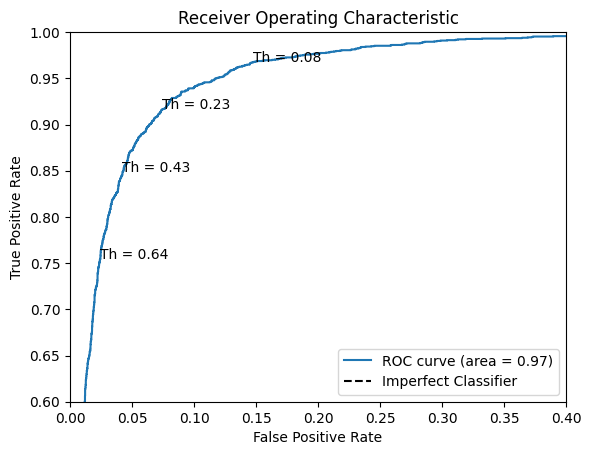

In [37]:
show_roc(y_val, y_val_proba_lr, steps=200)

In [38]:
# Threshold tuning (e.g., maximize recall or F1)
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba_lr)
best_idx = np.argmax(tpr - fpr)
best_threshold_lr = thresholds[best_idx]
best_threshold_lr

np.float64(0.20062904979776267)

In [39]:
# Predict with tuned threshold
y_val_pred_tuned_lr = (y_val_proba_lr >= best_threshold_lr).astype(int)
lr_tuned_report = classification_report(y_val, y_val_pred_tuned_lr)
print(f"Classification report after threshold tuning: \n{lr_tuned_report}")

lr_metrics_tuned = evaluate_model(y_val, y_val_pred_tuned_lr, y_proba=y_val_proba_lr)
print(f"F1-score (weighted): {lr_metrics_tuned['f1_weighted']:.4f}")
print(f"Recall: {lr_metrics_tuned['recall']:.4f}")
if lr_metrics_tuned['roc_auc'] is not None:
    print(f"ROC-AUC score: {lr_metrics_tuned['roc_auc']:.4f}")
print(f"Confusion matrix: {lr_metrics_tuned['confusion_matrix']}") 

Classification report after threshold tuning: 
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     10362
           1       0.72      0.93      0.81      2301

    accuracy                           0.92     12663
   macro avg       0.85      0.92      0.88     12663
weighted avg       0.93      0.92      0.92     12663

F1-score (weighted): 0.9237
Recall: 0.9233
ROC-AUC score: 0.9745
Confusion matrix: [[9511, 851], [164, 2137]]


In [40]:
lr_best_params_serializable = make_json_serializable(lr_best_params)
metadata_lr = {
    "model_name": 'logistic_regression',
    "best_score": lr_best_score,
    "best_params": lr_best_params_serializable,
    "metrics_default": lr_metrics_default,
    "metrics_tuned": lr_metrics_tuned,
    "best_threshold": float(best_threshold_lr),
}
metadata_lr

{'model_name': 'logistic_regression',
 'best_score': np.float64(0.938052243193205),
 'best_params': {'feature_selector': "SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',\n                                                 random_state=42),\n                threshold=0.01)",
  'feature_selector__estimator__max_depth': 10,
  'feature_selector__estimator__n_estimators': 200,
  'feature_selector__threshold': 0.001,
  'model__C': 10,
  'model__class_weight': None,
  'model__penalty': 'l2',
  'preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop': 'first'},
 'metrics_default': {'accuracy': 0.9384821922135355,
  'recall': 0.8932719013686303,
  'precision': 0.8985523989353197,
  'f1_macro': 0.8958801600594137,
  'f1_weighted': 0.9382770713179786,
  'roc_auc': 0.9744896628195776,
  'confusion_matrix': [[9992, 370], [409, 1892]]},
 'metrics_tuned': {'accuracy': 0.9198452183526811,
  'recall': 0.9232998190409396,
  'precision': 0.8491216026898292,


In [41]:
models_selection_results['logistic_regression'] = {
    # GridSearchCV results
    "estimator": lr_best_estimator,
    "best_score": lr_best_score,
    "best_params": lr_best_params,
    # Default threshold metrics
    "val_recall_default": lr_metrics_default["recall"],
    "val_precision_default": lr_metrics_default["precision"],
    "val_f1_weighted_default": lr_metrics_default["f1_weighted"],
    "val_roc_auc_default": lr_metrics_default["roc_auc"],
    # Tuned threshold metrics
    "val_recall_tuned": lr_metrics_tuned["recall"],
    "val_precision_tuned": lr_metrics_tuned["precision"],
    "val_f1_weighted_tuned": lr_metrics_tuned["f1_weighted"],
    "val_roc_auc_tuned": lr_metrics_tuned["roc_auc"],
    # Threshold info
    "best_threshold": best_threshold_lr
}

## 5.2 Evaluation RandomForest


In [42]:
y_val_pred_default_rf = rf_best_estimator.predict(X_val)
y_val_proba_rf = rf_best_estimator.predict_proba(X_val)[:, 1]

In [43]:
print("EVALUATION ON VALIDATION DATA | RANDOM FOREST CLASSIFIER")
rf_default_report = classification_report(y_val, y_val_pred_default_rf)
print(f"Classification report with default threshold:: \n {rf_default_report}")

rf_metrics_default = evaluate_model(y_val, y_val_pred_default_rf, y_proba=y_val_proba_rf)
print(f"F1-Score-weighted: {rf_metrics_default['f1_weighted']:.4f}")
print(f"Recall: {rf_metrics_default['recall']:.4f}")
if rf_metrics_default['roc_auc'] is not None:
    print(f"ROC-AUC score: {rf_metrics_default['roc_auc']:.4f}")
print(f"Confusion matrix: {rf_metrics_default['confusion_matrix']}")

EVALUATION ON VALIDATION DATA | RANDOM FOREST CLASSIFIER
Classification report with default threshold:: 
               precision    recall  f1-score   support

           0       0.98      0.92      0.95     10362
           1       0.72      0.92      0.80      2301

    accuracy                           0.92     12663
   macro avg       0.85      0.92      0.88     12663
weighted avg       0.93      0.92      0.92     12663

F1-Score-weighted: 0.9226
Recall: 0.9182
ROC-AUC score: 0.9731
Confusion matrix: [[9526, 836], [191, 2110]]


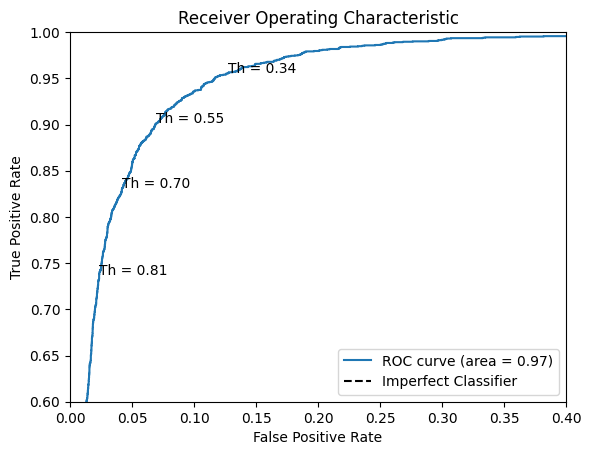

In [44]:
show_roc(y_val, y_val_proba_rf, steps=200)

In [45]:
# Threshold tuning (e.g., maximize recall or F1)
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba_rf)
best_idx = np.argmax(tpr - fpr)
best_threshold_rf = thresholds[best_idx]
best_threshold_rf

np.float64(0.4535738659653601)

In [46]:
# Predict with tuned threshold
y_val_pred_tuned_rf = (y_val_proba_rf >= best_threshold_rf).astype(int)
rf_tuned_report = classification_report(y_val, y_val_pred_tuned_rf)
print(f"Classification report after threshold tuning: \n{rf_tuned_report}")

rf_metrics_tuned = evaluate_model(y_val, y_val_pred_tuned_rf, y_proba=y_val_proba_rf)
print(f"F1-score (weighted): {rf_metrics_tuned['f1_weighted']:.4f}")
print(f"Recall: {rf_metrics_tuned['recall']:.4f}")
if rf_metrics_tuned['roc_auc'] is not None:
    print(f"ROC-AUC score: {rf_metrics_tuned['roc_auc']:.4f}")
print(f"Confusion matrix: {rf_metrics_tuned['confusion_matrix']}") 

Classification report after threshold tuning: 
              precision    recall  f1-score   support

           0       0.98      0.91      0.94     10362
           1       0.69      0.93      0.80      2301

    accuracy                           0.91     12663
   macro avg       0.84      0.92      0.87     12663
weighted avg       0.93      0.91      0.92     12663

F1-score (weighted): 0.9176
Recall: 0.9191
ROC-AUC score: 0.9731
Confusion matrix: [[9424, 938], [164, 2137]]


In [47]:
rf_best_params_serializable = make_json_serializable(rf_best_params)
metadata_rf = {
    "model_name": 'random_forest',
    "best_score": rf_best_score,
    "best_params": rf_best_params_serializable,
    "metrics_default": rf_metrics_default,
    "metrics_tuned": rf_metrics_tuned,
    "best_threshold": float(best_threshold_rf),
}
metadata_rf

{'model_name': 'random_forest',
 'best_score': np.float64(0.922986478542034),
 'best_params': {'feature_selector': "SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',\n                                                 random_state=42),\n                threshold=0.01)",
  'feature_selector__estimator__max_depth': 10,
  'feature_selector__threshold': 0.001,
  'model__max_depth': 10,
  'model__min_samples_leaf': 2,
  'model__n_estimators': 100,
  'preprocess__standard_preprocessor__categorical__cat_multiclass__encoder__drop': None},
 'metrics_default': {'accuracy': 0.9188975756139935,
  'recall': 0.9181566031938482,
  'precision': 0.8482845589238588,
  'f1_macro': 0.8765605703098831,
  'f1_weighted': 0.9225797989717539,
  'roc_auc': 0.9730727667141357,
  'confusion_matrix': [[9526, 836], [191, 2110]]},
 'metrics_tuned': {'accuracy': 0.9129748084971966,
  'recall': 0.9191017877728447,
  'precision': 0.83892731768369,
  'f1_macro': 0.8698883928571428,
  'f1_weighted':

In [48]:
models_selection_results['random_forest'] = {
    # GridSearchCV results
    "estimator": rf_best_estimator,
    "best_score": rf_best_score,
    "best_params": rf_best_params,
    # Default threshold metrics
    "val_recall_default": rf_metrics_default["recall"],
    "val_precision_default": rf_metrics_default["precision"],
    "val_f1_weighted_default": rf_metrics_default["f1_weighted"],
    "val_roc_auc_default": rf_metrics_default["roc_auc"],
    # Tuned threshold metrics
    "val_recall_tuned": rf_metrics_tuned["recall"],
    "val_precision_tuned": rf_metrics_tuned["precision"],
    "val_f1_weighted_tuned": rf_metrics_tuned["f1_weighted"],
    "val_roc_auc_tuned": rf_metrics_tuned["roc_auc"],
    # Threshold info
    "best_threshold": best_threshold_rf
}

In [49]:
models_selection_df = pd.DataFrame(models_selection_results).T
models_selection_df

,estimator,best_score,best_params,val_recall_default,val_precision_default,val_f1_weighted_default,val_roc_auc_default,val_recall_tuned,val_precision_tuned,val_f1_weighted_tuned,val_roc_auc_tuned,best_threshold
logistic_regression,"((InconsistencyFlagger(), ConditionalFlagger(f...",0.938052,{'feature_selector': SelectFromModel(estimator...,0.893272,0.898552,0.938277,0.97449,0.9233,0.849122,0.923677,0.97449,0.200629
random_forest,"((InconsistencyFlagger(), ConditionalFlagger(f...",0.922986,{'feature_selector': SelectFromModel(estimator...,0.918157,0.848285,0.92258,0.973073,0.919102,0.838927,0.917551,0.973073,0.453574


# 6. Model selection & evaluation

- Select the best-performing model based on scores of the models while tuning.
- Retrain the model on full train data (X_full_train, y_full_train)
- Predict on test set and evaluate.

In [50]:
models_selection_df

,estimator,best_score,best_params,val_recall_default,val_precision_default,val_f1_weighted_default,val_roc_auc_default,val_recall_tuned,val_precision_tuned,val_f1_weighted_tuned,val_roc_auc_tuned,best_threshold
logistic_regression,"((InconsistencyFlagger(), ConditionalFlagger(f...",0.938052,{'feature_selector': SelectFromModel(estimator...,0.893272,0.898552,0.938277,0.97449,0.9233,0.849122,0.923677,0.97449,0.200629
random_forest,"((InconsistencyFlagger(), ConditionalFlagger(f...",0.922986,{'feature_selector': SelectFromModel(estimator...,0.918157,0.848285,0.92258,0.973073,0.919102,0.838927,0.917551,0.973073,0.453574


In [51]:
best_model_name = models_selection_df["val_f1_weighted_tuned"].idxmax()
best_model_name

'logistic_regression'

In [52]:
best_row = models_selection_df.loc[best_model_name]
best_row

estimator                  ((InconsistencyFlagger(), ConditionalFlagger(f...
best_score                                                          0.938052
best_params                {'feature_selector': SelectFromModel(estimator...
val_recall_default                                                  0.893272
val_precision_default                                               0.898552
val_f1_weighted_default                                             0.938277
val_roc_auc_default                                                  0.97449
val_recall_tuned                                                      0.9233
val_precision_tuned                                                 0.849122
val_f1_weighted_tuned                                               0.923677
val_roc_auc_tuned                                                    0.97449
best_threshold                                                      0.200629
Name: logistic_regression, dtype: object

In [53]:
best_threshold = best_row["best_threshold"]
best_model = best_row["estimator"]

In [54]:
from sklearn.base import clone
final_model = clone(best_model)

In [55]:
final_model.fit(X_full_train, y_full_train)

,steps,"[('preprocess', ...), ('feature_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('inconsistency_flagger', ...), ('conditional_flagger', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,flagging_map,"{'academic_pressure': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'cgpa': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, 'job_satisfaction': {'imputed': {'occupation_status': 'Working Professional'}, 'not_applicable': {'occupation_status': 'Student'}}, 'study_satisfaction': {'imputed': {'occupation_status': 'Student'}, 'not_applicable': {'occupation_status': 'Working Professional'}}, ...}"
,suffix_map,"{'imputed': '_imputed', 'not_applicable': '_not_applicable'}"
,steps,"[('custom_cat', ...), ('custom_num', ...), ...]"


In [56]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]
report_default = classification_report(y_test, y_pred)
print(report_default)

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     11513
           1       0.85      0.81      0.83      2557

    accuracy                           0.94     14070
   macro avg       0.90      0.89      0.90     14070
weighted avg       0.94      0.94      0.94     14070



In [57]:
y_pred_threshold = (y_proba >= best_threshold).astype(int)
report_tuned = classification_report(y_test, y_pred_threshold)
print(report_tuned)

              precision    recall  f1-score   support

           0       0.98      0.92      0.95     11513
           1       0.72      0.92      0.80      2557

    accuracy                           0.92     14070
   macro avg       0.85      0.92      0.88     14070
weighted avg       0.93      0.92      0.92     14070



In [58]:
metrics_default = evaluate_model(y_test, y_pred, y_proba)
metrics_default

{'accuracy': 0.9392324093816631,
 'recall': 0.8900061826692929,
 'precision': 0.9027722701004264,
 'f1_macro': 0.8962043977114329,
 'f1_weighted': 0.9387431848312676,
 'roc_auc': 0.974011014941162,
 'confusion_matrix': [[11137, 376], [479, 2078]]}

In [59]:
metrics_tuned = evaluate_model(y_test, y_pred_threshold, y_proba)
metrics_tuned

{'accuracy': 0.9189765458422174,
 'recall': 0.9194598029854606,
 'precision': 0.8482464209286356,
 'f1_macro': 0.8769300169006964,
 'f1_weighted': 0.9227190141283548,
 'roc_auc': 0.974011014941162,
 'confusion_matrix': [[10577, 936], [204, 2353]]}

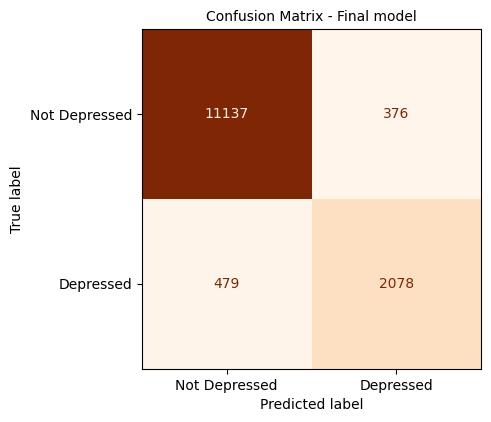

In [60]:
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Depressed", "Depressed"])
disp.plot(cmap='Oranges', ax=axes, colorbar=False, values_format='.0f')
axes.set_title("Confusion Matrix - Final model", fontsize=10)
plt.tight_layout()
plt.show()

# 7. Predcitions on external data 

## 7.1 Load and prepare external data

In [63]:
from pathlib import Path 
ROOT = Path.cwd().parent
DATA = ROOT / "data"

In [65]:
test_path = DATA/"external"/"external_data.csv"
columns_names =['id', 'name', 'gender', 'age', 'city', 'occupation_status', 'profession', 
                'academic_pressure', 'work_pressure', 'cgpa', 'study_satisfaction', 'job_satisfaction', 
                'sleep_duration', 'dietary_habits', 'degree', 'suicidal_thoughts', 'work_study_hours', 
                'financial_stress', 'family_history_mental_illness', 'depression']

external_df = pd.read_csv(test_path, names=columns_names[:-1], header=0) 
external_df.head()

,id,name,gender,age,city,occupation_status,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history_mental_illness
0,140700,Shivam,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,140701,Sanya,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No
2,140702,Yash,Male,53.0,Jaipur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,B.Arch,Yes,12.0,4.0,No
3,140703,Nalini,Female,23.0,Rajkot,Student,NaN,5.0,NaN,6.84,1.0,NaN,More than 8 hours,Moderate,BSc,Yes,10.0,4.0,No
4,140704,Shaurya,Male,47.0,Kalyan,Working Professional,Teacher,NaN,5.0,NaN,NaN,5.0,7-8 hours,Moderate,BCA,Yes,3.0,4.0,No


In [66]:
# ids is needed for the prediction (later)
ids = external_df['id'].copy()
external_df = external_df.drop(["name", "id"], axis=1)
external_df.head()

,gender,age,city,occupation_status,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history_mental_illness
0,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No
2,Male,53.0,Jaipur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,B.Arch,Yes,12.0,4.0,No
3,Female,23.0,Rajkot,Student,NaN,5.0,NaN,6.84,1.0,NaN,More than 8 hours,Moderate,BSc,Yes,10.0,4.0,No
4,Male,47.0,Kalyan,Working Professional,Teacher,NaN,5.0,NaN,NaN,5.0,7-8 hours,Moderate,BCA,Yes,3.0,4.0,No


## 7.2 Predict

In [67]:
probs = final_model.predict_proba(external_df)[:, 1]
predictions = (probs >= best_threshold).astype(int)
output = pd.DataFrame({'id': ids, 'Depression': predictions})
output

,id,Depression
0,140700,0
1,140701,0
2,140702,0
3,140703,1
4,140704,0
...,...,...
93795,234495,0
93796,234496,1
93797,234497,0
93798,234498,1


In [68]:
# predictions_output_path = 'output/external_data_predictions.csv'
# output.to_csv(predictions_output_path, index=False)
# print(f"Predictions saved to {predictions_output_path}")

# 8. Deployment 

- organize code into reusable modules & scripts ->>> GITHUB 

# Conclusion and next step
This notebook delivered a comprehensive end-to-end workflow for predicting depression risk using anonymized survey data that captures demographic, academic, occupational, lifestyle, and psychological factors. The process began with detailed data exploration and visualization to understand feature distributions, correlations, and potential data quality issues. Careful preprocessing addressed missing values, high-cardinality features, and logical inconsistencies, while custom feature engineering and imputation strategies ensured both students and working professionals were accurately represented.

Feature selection was performed using a model-based approach to isolate the most predictive variables. Subsequently, both Logistic Regression and Random Forest models were trained and rigorously tuned with GridSearchCV, optimizing not only model hyperparameters but also feature selection thresholds. Model performance was evaluated and the best-performing model was identified for final prediction and deployment.

**Potential next steps for further enhancement include:**
- Implementing deep learning model, such as Multi-Layer Perceptron (MLP)
- Implementing XGBoost model